In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:

df = pd.read_csv('Clean_Dataset_ATS_v2.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

In [7]:
import os
print(os.listdir('/content'))

['.config', 'Clean_Dataset_ATS_v2.csv', 'sample_data']


In [9]:
import pandas as pd

df = pd.read_csv('/content/Clean_Dataset_ATS_v2.csv')

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (7043, 15)


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,ServiceCount,InternetService,Contract_Month-to-month,Contract_One year,Contract_Two year,ContractMonths,MonthlyCharges,MonthlyChargePerService,Churn
0,0,0,0,1,0,0,0,0,1,0,0,0,25,25.0,1
1,1,0,0,41,1,0,1,0,0,1,0,12,25,12.5,0
2,0,0,1,52,1,0,1,0,1,0,0,0,19,9.5,0
3,0,0,0,1,1,0,1,0,0,1,0,12,76,38.0,1
4,1,0,0,67,1,0,1,1,1,0,0,0,51,25.5,0


In [10]:
print("Missing values in clustering features:")
print(df[['tenure', 'MonthlyCharges']].isnull().sum())

print("\nBasic statistics:")
print(df[['tenure', 'MonthlyCharges']].describe())

Missing values in clustering features:
tenure            0
MonthlyCharges    0
dtype: int64

Basic statistics:
            tenure  MonthlyCharges
count  7043.000000     7043.000000
mean     32.371149       64.758768
std      24.559481       30.091650
min       0.000000       18.000000
25%       9.000000       36.000000
50%      29.000000       70.000000
75%      55.000000       90.000000
max      72.000000      119.000000


In [11]:
from sklearn.preprocessing import StandardScaler

# Select clustering features
X = df[['tenure', 'MonthlyCharges']]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("First 5 rows before scaling:")
print(X.head())

print("\nFirst 5 rows after scaling:")
print(X_scaled[:5])

First 5 rows before scaling:
   tenure  MonthlyCharges
0       1              25
1      41              25
2      52              19
3       1              76
4      67              51

First 5 rows after scaling:
[[-1.27744458 -1.32134962]
 [ 0.35136997 -1.32134962]
 [ 0.79929397 -1.52075464]
 [-1.27744458  0.37359302]
 [ 1.41009942 -0.45726121]]


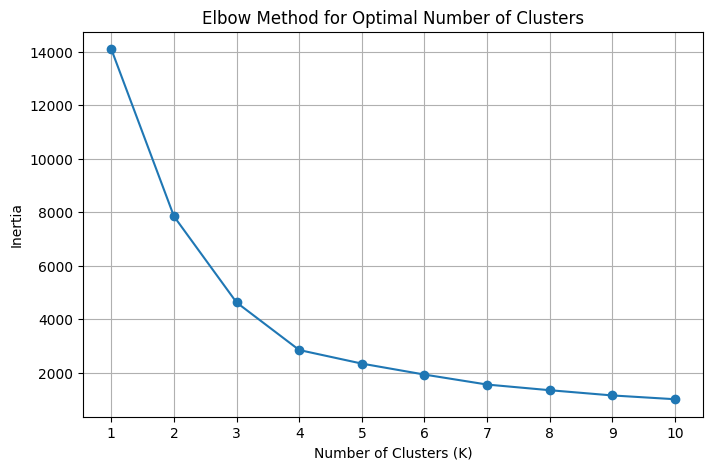

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xticks(K_range)
plt.grid(True)

# Save the graph for Stage 2 submission
plt.savefig(
    'Elbow_Method.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [13]:
from sklearn.metrics import silhouette_score

print("Silhouette Scores:")

for k in range(2, 7):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    print(f"K = {k}: {score:.3f}")

Silhouette Scores:
K = 2: 0.411
K = 3: 0.446
K = 4: 0.476
K = 5: 0.430
K = 6: 0.415


In [14]:
# Train final K-Means model with 4 clusters
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Assign each customer to a cluster
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("K-Means model trained successfully.")
print("\nNumber of customers in each cluster:")
print(df['Cluster'].value_counts().sort_index())

K-Means model trained successfully.

Number of customers in each cluster:
Cluster
0    2202
1    1733
2    1948
3    1160
Name: count, dtype: int64


In [15]:
# Calculate the average tenure and monthly charges for each cluster
cluster_summary = df.groupby('Cluster').agg(
    Customer_Count=('Cluster', 'size'),
    Average_Tenure=('tenure', 'mean'),
    Average_Monthly_Charges=('MonthlyCharges', 'mean')
)

cluster_summary = cluster_summary.round(2)

print(cluster_summary)

         Customer_Count  Average_Tenure  Average_Monthly_Charges
Cluster                                                         
0                  2202           14.81                    81.23
1                  1733           10.48                    32.49
2                  1948           58.76                    93.08
3                  1160           54.10                    34.15


In [16]:
# Create final cluster summary
cluster_results = df.groupby('Cluster').agg(
    Customer_Count=('Cluster', 'size'),
    Average_Tenure=('tenure', 'mean'),
    Average_Monthly_Charges=('MonthlyCharges', 'mean'),
    Churn_Rate=('Churn', 'mean')
)

# Convert churn rate to percentage
cluster_results['Churn_Rate'] = cluster_results['Churn_Rate'] * 100

# Calculate percentage of customers in each cluster
cluster_results['Customer_Percentage'] = (
    cluster_results['Customer_Count'] / len(df) * 100
)

# Add meaningful segment names
segment_names = {
    0: 'Newer - High Charges',
    1: 'Newer - Low Charges',
    2: 'Long-term - High Charges',
    3: 'Long-term - Low Charges'
}

cluster_results['Customer_Segment'] = (
    cluster_results.index.map(segment_names)
)

# Round the numbers
cluster_results = cluster_results.round(2)

cluster_results

,Customer_Count,Average_Tenure,Average_Monthly_Charges,Churn_Rate,Customer_Percentage,Customer_Segment
Cluster,,,,,,
0,2202,14.81,81.23,49.18,31.27,Newer - High Charges
1,1733,10.48,32.49,24.47,24.61,Newer - Low Charges
2,1948,58.76,93.08,15.71,27.66,Long-term - High Charges
3,1160,54.10,34.15,4.83,16.47,Long-term - Low Charges


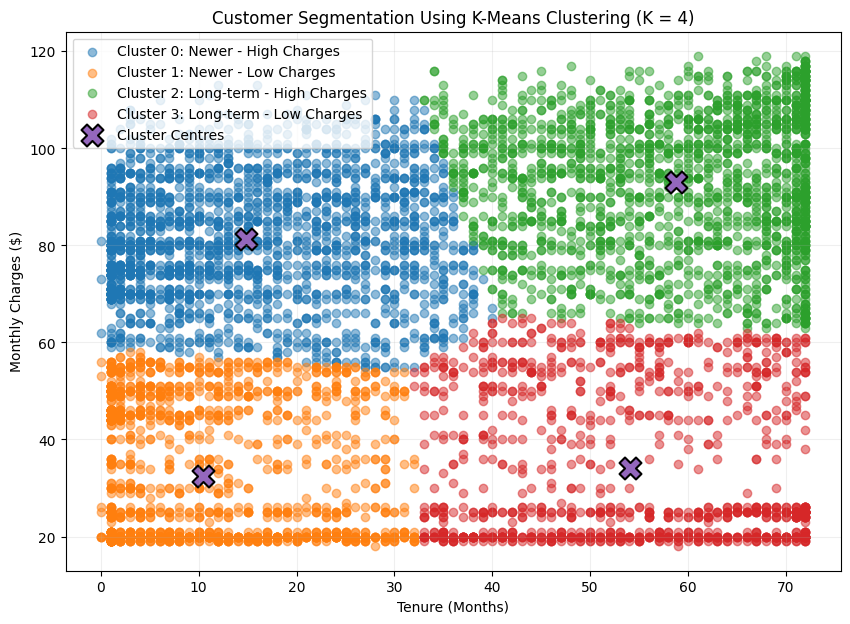

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

segment_names = {
    0: 'Newer - High Charges',
    1: 'Newer - Low Charges',
    2: 'Long-term - High Charges',
    3: 'Long-term - Low Charges'
}

# Plot each cluster
for cluster in range(4):
    cluster_data = df[df['Cluster'] == cluster]

    plt.scatter(
        cluster_data['tenure'],
        cluster_data['MonthlyCharges'],
        alpha=0.5,
        label=f'Cluster {cluster}: {segment_names[cluster]}'
    )

# Calculate centres in original units for easy interpretation
centres = df.groupby('Cluster')[['tenure', 'MonthlyCharges']].mean()

plt.scatter(
    centres['tenure'],
    centres['MonthlyCharges'],
    marker='X',
    s=250,
    edgecolors='black',
    linewidths=1.5,
    label='Cluster Centres'
)

plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges ($)')
plt.title('Customer Segmentation Using K-Means Clustering (K = 4)')
plt.legend()
plt.grid(alpha=0.2)

# Save high-quality image
plt.savefig(
    'KMeans_Cluster_Visualisation.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

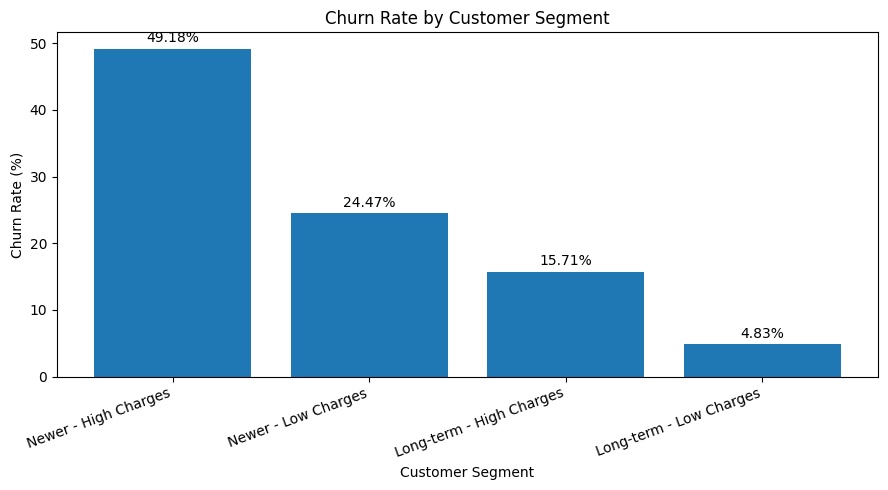

In [18]:
# Calculate churn rate for each cluster
churn_rates = df.groupby('Cluster')['Churn'].mean() * 100

segment_labels = [
    'Newer - High Charges',
    'Newer - Low Charges',
    'Long-term - High Charges',
    'Long-term - Low Charges'
]

plt.figure(figsize=(9, 5))

bars = plt.bar(segment_labels, churn_rates)

plt.xlabel('Customer Segment')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Customer Segment')
plt.xticks(rotation=20, ha='right')

# Add percentage above each bar
for bar, rate in zip(bars, churn_rates):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{rate:.2f}%',
        ha='center'
    )

plt.tight_layout()

plt.savefig(
    'Churn_Rate_by_Segment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [19]:
import joblib

# Save the trained K-Means model
joblib.dump(kmeans, 'kmeans_model.pkl')

# Save the fitted scaler
joblib.dump(scaler, 'scaler.pkl')

print("K-Means model saved as: kmeans_model.pkl")
print("Scaler saved as: scaler.pkl")

K-Means model saved as: kmeans_model.pkl
Scaler saved as: scaler.pkl
